# Уменьшение размерности методом PCA — Экспрессия генов рака молочной железы

**PCA (Principal Component Analysis, метод главных компонент)** — один из фундаментальных методов уменьшения размерности данных. Идея PCA заключается в поиске таких ортогональных направлений 
(главных компонент) в пространстве признаков, вдоль которых дисперсия данных максимальна. Проецируя данные на первые K главных компонент, мы сохраняем максимум информации при минимальном числе признаков. PCA особенно полезен для визуализации высокоразмерных данных, устранения мультиколлинеарности, ускорения обучения моделей и борьбы с «проклятием размерности». 

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, f1_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("Все библиотеки успешно импортированы!")

Все библиотеки успешно импортированы!


## Описание датасета

https://www.kaggle.com/datasets/brunogrisci/breast-cancer-gene-expression-cumida

### Краткое описание датасета

**Breast Cancer Gene Expression (CuMiDa)** — датасет экспрессии генов, полученный методом микрочипов (microarray). Содержит уровни экспрессии тысяч генов для образцов тканей молочной 
железы с различными типами рака.

### Структура датасета:

| Элемент | Описание |
|---------|----------|
| **Строки** | Образцы тканей (пациенты) |
| **Столбцы (признаки)** | Уровни экспрессии отдельных генов (тысячи генов) |
| **Целевая переменная** | Тип рака молочной железы (несколько классов) |


In [2]:
df = pd.read_csv('/kaggle/input/datasets/brunogrisci/breast-cancer-gene-expression-cumida/Breast_GSE45827.csv')

print("=" * 60)
print("ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
print(f"\nРазмер: {df.shape[0]} строк (образцов), {df.shape[1]} столбцов")
print(f"Количество генов (признаков): {df.shape[1] - 1}")
print(f"\nПервые 5 столбцов: {list(df.columns[:5])}")
print(f"Последние 5 столбцов: {list(df.columns[-5:])}")

print("\n" + "=" * 60)
print("ПЕРВЫЕ 5 СТРОК (первые 8 столбцов)")
print("=" * 60)
df.iloc[:5, :8]

ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Размер: 151 строк (образцов), 54677 столбцов
Количество генов (признаков): 54676

Первые 5 столбцов: ['samples', 'type', '1007_s_at', '1053_at', '117_at']
Последние 5 столбцов: ['AFFX-ThrX-5_at', 'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at', 'AFFX-TrpnX-5_at', 'AFFX-TrpnX-M_at']

ПЕРВЫЕ 5 СТРОК (первые 8 столбцов)


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457


Столбец с метками: 'type'

РАСПРЕДЕЛЕНИЕ КЛАССОВ
type
basal        41
HER          30
luminal_B    30
luminal_A    29
cell_line    14
normal        7
Name: count, dtype: int64


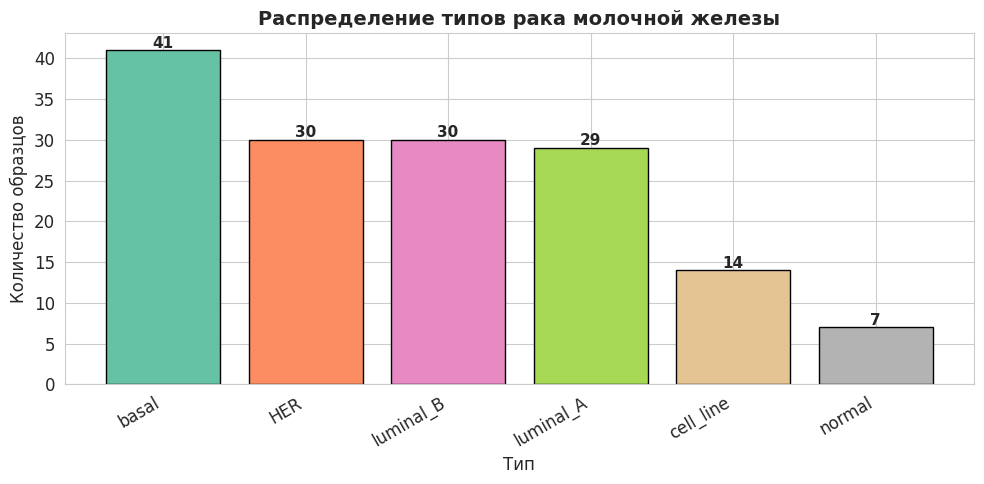

In [3]:
# Определяем столбец с метками
# Обычно первый или последний столбец
label_col = 'type' if 'type' in df.columns else df.columns[0]
print(f"Столбец с метками: '{label_col}'")

print("\n" + "=" * 60)
print("РАСПРЕДЕЛЕНИЕ КЛАССОВ")
print("=" * 60)
print(df[label_col].value_counts())

fig, ax = plt.subplots(figsize=(10, 5))
colors_cls = plt.cm.Set2(np.linspace(0, 1, df[label_col].nunique()))
counts = df[label_col].value_counts()
bars = ax.bar(counts.index, counts.values, color=colors_cls, edgecolor='black')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(v), ha='center', fontweight='bold', fontsize=11)
ax.set_title('Распределение типов рака молочной железы', fontsize=14, fontweight='bold')
ax.set_xlabel('Тип', fontsize=12)
ax.set_ylabel('Количество образцов', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [4]:
print("=" * 60)
print("СТАТИСТИКА ЭКСПРЕССИИ ГЕНОВ (первые 10 генов)")
print("=" * 60)
gene_cols = [c for c in df.columns if c != label_col]
df[gene_cols[:10]].describe().round(2)

СТАТИСТИКА ЭКСПРЕССИИ ГЕНОВ (первые 10 генов)


,samples,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at
count,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00,151.00
mean,160.67,10.34,7.63,6.22,7.34,3.19,7.31,5.32,4.71,7.79
std,45.43,0.61,0.71,0.65,0.33,0.16,0.64,0.29,0.31,1.65
min,84.00,7.51,5.86,4.76,6.63,2.76,5.46,4.65,3.95,3.87
25%,121.50,10.10,7.17,5.80,7.11,3.08,6.87,5.13,4.47,6.80
50%,159.00,10.42,7.53,6.24,7.33,3.19,7.42,5.27,4.66,7.91
75%,200.50,10.74,8.05,6.61,7.51,3.28,7.76,5.46,4.94,8.89
max,238.00,11.68,9.63,8.36,8.37,3.61,8.57,6.36,5.89,11.71


## Предварительная обработка датасета

In [5]:
# Разделяем признаки и метки
X_raw = df.drop(columns=[label_col])
y_raw = df[label_col]

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = le.classes_

print(f"Признаков (генов): {X_raw.shape[1]}")
print(f"Образцов: {X_raw.shape[0]}")
print(f"Классы: {list(class_names)}")
print(f"Пропуски: {X_raw.isnull().sum().sum()}")

# Заполнение пропусков медианой (если есть)
if X_raw.isnull().sum().sum() > 0:
    X_raw = X_raw.fillna(X_raw.median())

Признаков (генов): 54676
Образцов: 151
Классы: ['HER', 'basal', 'cell_line', 'luminal_A', 'luminal_B', 'normal']
Пропуски: 0


In [6]:
# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"\nМасштабирование выполнено!")
print(f"Размер данных: {X_scaled.shape} — это {X_scaled.shape[1]} признаков на {X_scaled.shape[0]} образцов")
print(f"Отношение p/n = {X_scaled.shape[1]/X_scaled.shape[0]:.0f}x (признаков в {X_scaled.shape[1]//X_scaled.shape[0]} раз больше, чем образцов)")


Масштабирование выполнено!
Размер данных: (151, 54676) — это 54676 признаков на 151 образцов
Отношение p/n = 362x (признаков в 362 раз больше, чем образцов)


In [7]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение классов (train):")
for i, name in enumerate(class_names):
    cnt = (y_train == i).sum()
    print(f"  {name}: {cnt}")

Обучающая выборка: (120, 54676)
Тестовая выборка: (31, 54676)

Распределение классов (train):
  HER: 24
  basal: 33
  cell_line: 11
  luminal_A: 23
  luminal_B: 24
  normal: 5


## Тепловая карта корреляций (Heatmap)

Для 50 000+ генов полная матрица корреляций невозможна. 
Вместо этого строим корреляцию для **20 самых вариабельных генов**.

In [8]:
# Топ-20 генов по дисперсии
variances = X_raw.var().sort_values(ascending=False)
top_genes = variances.head(20).index.tolist()

print(f"Топ-20 генов по дисперсии:")
for i, g in enumerate(top_genes, 1):
    print(f"  {i:2d}. {g}: var = {variances[g]:.2f}")

Топ-20 генов по дисперсии:
   1. samples: var = 2064.00
   2. 206378_at: var = 17.08
   3. 228241_at: var = 13.37
   4. 205916_at: var = 11.14
   5. 237339_at: var = 10.87
   6. 1553602_at: var = 10.69
   7. 209173_at: var = 10.67
   8. 214451_at: var = 10.23
   9. 205009_at: var = 9.88
  10. 205044_at: var = 9.77
  11. 202917_s_at: var = 9.74
  12. 206799_at: var = 9.74
  13. 229152_at: var = 9.26
  14. 206509_at: var = 9.17
  15. 203757_s_at: var = 8.76
  16. 211430_s_at: var = 8.76
  17. 205225_at: var = 8.64
  18. 223864_at: var = 8.53
  19. 204304_s_at: var = 8.44
  20. 207802_at: var = 8.35


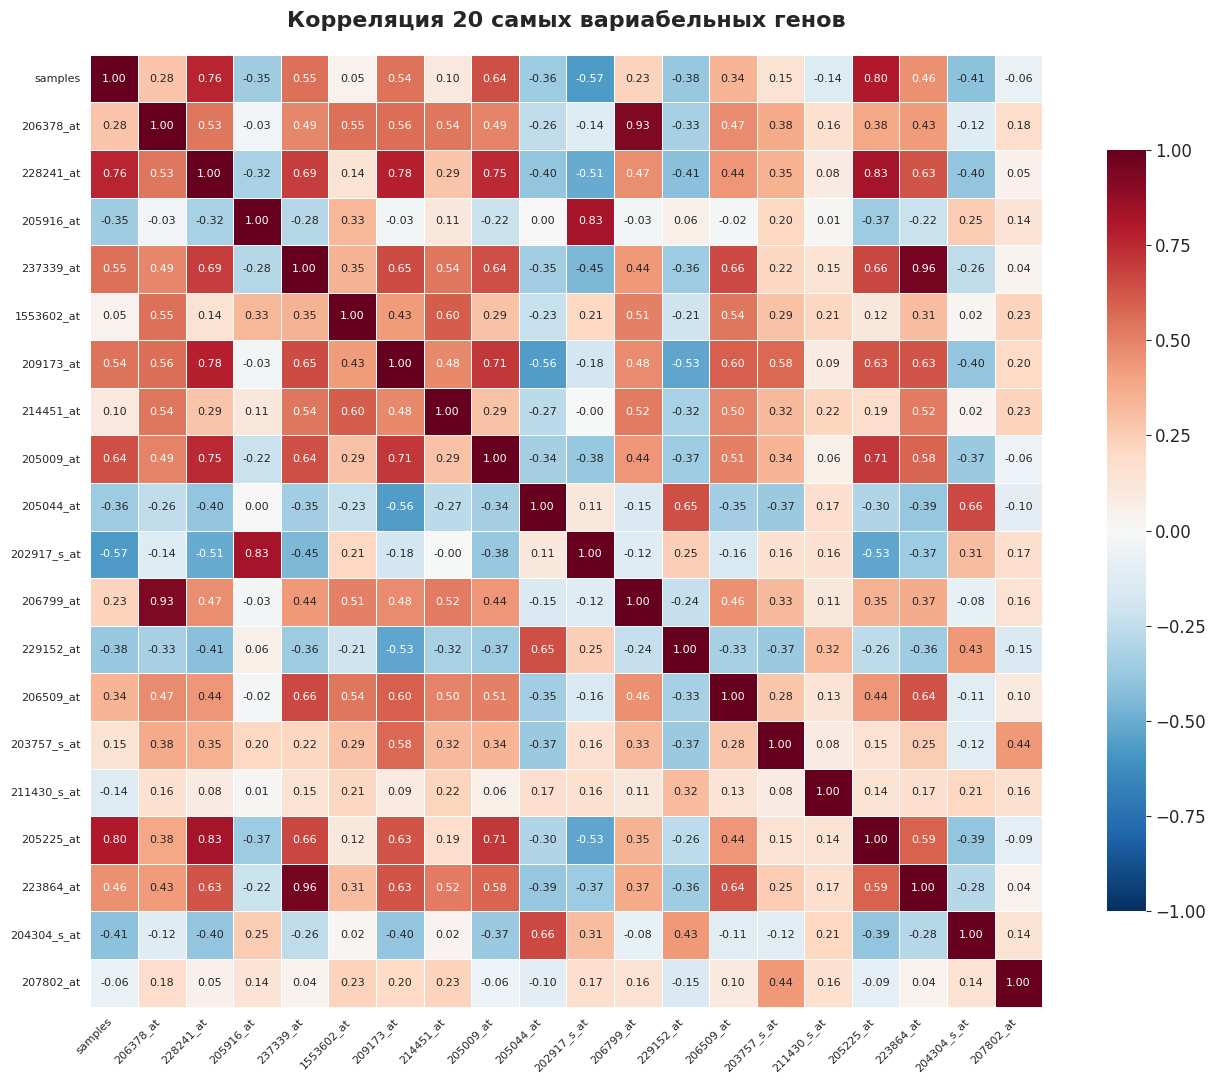

In [9]:
fig, ax = plt.subplots(figsize=(14, 11))

corr_top = X_raw[top_genes].corr()

sns.heatmap(
    corr_top, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Корреляция 20 самых вариабельных генов',
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## Анализ PCA: объяснённая дисперсия

Перед подбором параметров посмотрим, сколько компонент нужно для сохранения 80%, 90%, 95% и 99% дисперсии.

In [10]:
# Полный PCA на обучающей выборке
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Сколько компонент для разных порогов
thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]
print("=" * 60)
print("КОЛИЧЕСТВО КОМПОНЕНТ ДЛЯ РАЗНЫХ ПОРОГОВ ДИСПЕРСИИ")
print("=" * 60)
for t in thresholds:
    n = np.argmax(cumulative >= t) + 1
    print(f"  {t*100:.0f}% дисперсии: {n} компонент (из {X_train.shape[1]})")

print(f"\n  Первые 2 компоненты: {cumulative[1]*100:.1f}%")
print(f"  Первые 5 компонент: {cumulative[4]*100:.1f}%")
print(f"  Первые 10 компонент: {cumulative[9]*100:.1f}%")

КОЛИЧЕСТВО КОМПОНЕНТ ДЛЯ РАЗНЫХ ПОРОГОВ ДИСПЕРСИИ
  80% дисперсии: 61 компонент (из 54676)
  85% дисперсии: 73 компонент (из 54676)
  90% дисперсии: 86 компонент (из 54676)
  95% дисперсии: 101 компонент (из 54676)
  99% дисперсии: 115 компонент (из 54676)

  Первые 2 компоненты: 22.1%
  Первые 5 компонент: 34.2%
  Первые 10 компонент: 44.1%


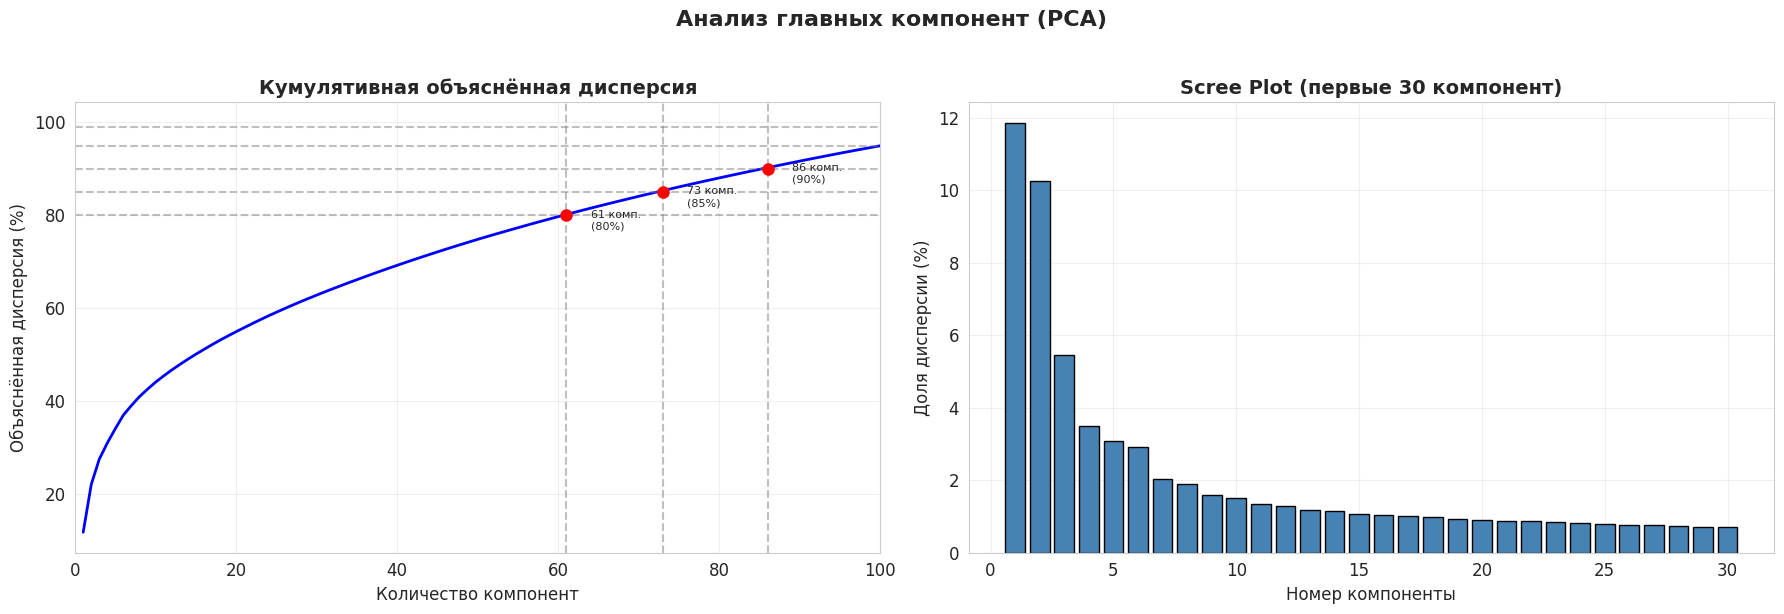

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Кумулятивная дисперсия
axes[0].plot(range(1, len(cumulative)+1), cumulative*100, 'b-', lw=2)
for t in thresholds:
    n = np.argmax(cumulative >= t) + 1
    axes[0].axhline(y=t*100, color='gray', linestyle='--', alpha=0.5)
    axes[0].axvline(x=n, color='gray', linestyle='--', alpha=0.5)
    axes[0].plot(n, t*100, 'ro', ms=8)
    axes[0].annotate(f'{n} комп.\n({t*100:.0f}%)', xy=(n, t*100),
                     xytext=(n+3, t*100-3), fontsize=8)
axes[0].set_title('Кумулятивная объяснённая дисперсия', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Количество компонент')
axes[0].set_ylabel('Объяснённая дисперсия (%)')
axes[0].set_xlim(0, min(100, len(cumulative)))
axes[0].grid(True, alpha=0.3)

# Scree plot (первые 30 компонент)
n_show = min(30, len(explained))
axes[1].bar(range(1, n_show+1), explained[:n_show]*100, color='steelblue', edgecolor='black')
axes[1].set_title('Scree Plot (первые 30 компонент)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Номер компоненты')
axes[1].set_ylabel('Доля дисперсии (%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Анализ главных компонент (PCA)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

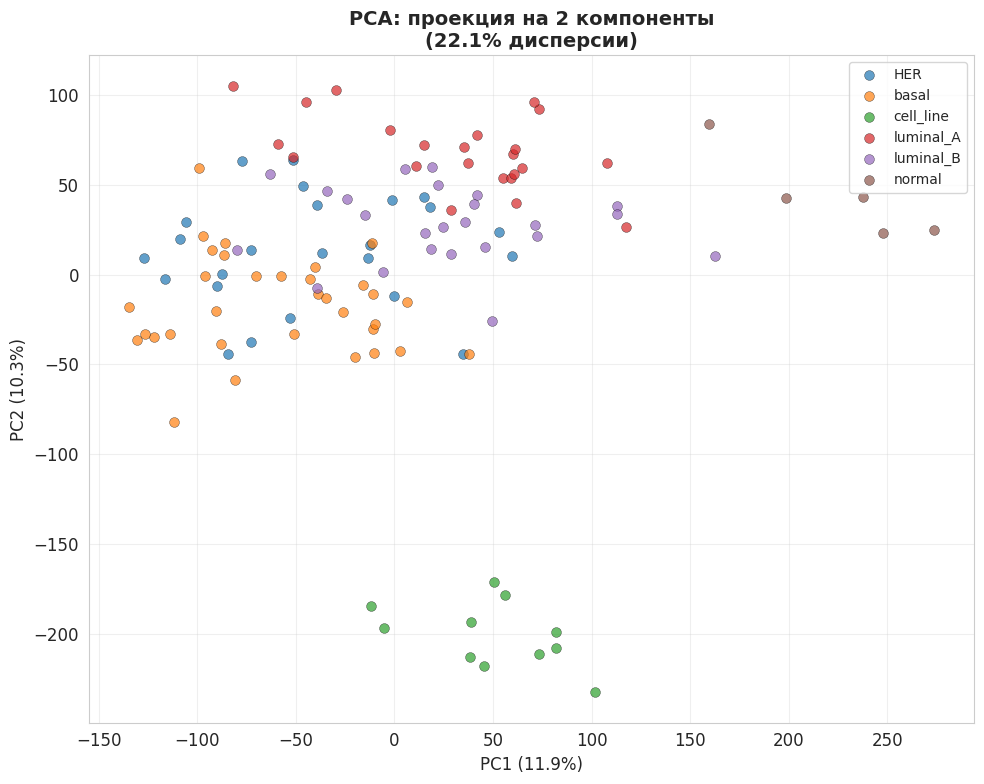

In [12]:
# Визуализация в 2D
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train)
X_test_2d = pca_2d.transform(X_test)

fig, ax = plt.subplots(figsize=(10, 8))
for i, name in enumerate(class_names):
    mask = y_train == i
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], alpha=0.7, s=50,
               label=name, edgecolors='black', linewidths=0.3)

ax.set_title(f'PCA: проекция на 2 компоненты\n'
             f'({pca_2d.explained_variance_ratio_.sum()*100:.1f}% дисперсии)',
             fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Подбор параметров PCA + классификатор

In [14]:
# Шаг 1: Предварительное снижение размерности
print("=" * 60)
print("ШАГ 1: ПРЕДВАРИТЕЛЬНОЕ СНИЖЕНИЕ РАЗМЕРНОСТИ")
print("=" * 60)

pca_pre = PCA(n_components=120, random_state=42)
X_train_pre = pca_pre.fit_transform(X_train)
X_test_pre = pca_pre.transform(X_test)

print(f"  Исходных признаков:       {X_train.shape[1]}")
print(f"  После предварительного PCA: {X_train_pre.shape[1]}")
print(f"  Объяснённая дисперсия:     {pca_pre.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Сжатие в {X_train.shape[1] / X_train_pre.shape[1]:.0f} раз")

ШАГ 1: ПРЕДВАРИТЕЛЬНОЕ СНИЖЕНИЕ РАЗМЕРНОСТИ
  Исходных признаков:       54676
  После предварительного PCA: 120
  Объяснённая дисперсия:     100.0%
  Сжатие в 456 раз


In [15]:
# Шаг 2: GridSearchCV на сжатых данных
print("\n" + "=" * 60)
print("ШАГ 2: ПОДБОР ПАРАМЕТРОВ (GridSearchCV, cv=3)")
print("=" * 60)

pipe = Pipeline([
    ('pca', PCA(random_state=42)),
    ('clf', LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = {
    'pca__n_components': [2, 5, 10, 20, 30, 50, 75, 100],
    'pca__whiten': [True, False],
    'pca__svd_solver': ['full', 'arpack', 'randomized', 'covariance_eigh']
}

print(f"\nPipeline: PCA → LogisticRegression (C=1, по умолчанию)")
print(f"Данные: {X_train_pre.shape} (после предварительного PCA)")
print(f"\nСетка параметров:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")

total = np.prod([len(v) for v in param_grid.values()])
print(f"\nВсего комбинаций: {total}")
print(f"С cv=3: {total * 3} обучений")
print("\nОбучение...")

grid_search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_pre, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучшая accuracy (cv=3): {grid_search.best_score_:.4f}")


ШАГ 2: ПОДБОР ПАРАМЕТРОВ (GridSearchCV, cv=3)

Pipeline: PCA → LogisticRegression (C=1, по умолчанию)
Данные: (120, 120) (после предварительного PCA)

Сетка параметров:
  pca__n_components: [2, 5, 10, 20, 30, 50, 75, 100]
  pca__whiten: [True, False]
  pca__svd_solver: ['full', 'arpack', 'randomized', 'covariance_eigh']

Всего комбинаций: 64
С cv=3: 192 обучений

Обучение...
Fitting 3 folds for each of 64 candidates, totalling 192 fits

Лучшие параметры: {'pca__n_components': 50, 'pca__svd_solver': 'full', 'pca__whiten': True}
Лучшая accuracy (cv=3): 0.9333


In [16]:
print("=" * 70)
print("ЛУЧШИЕ ПАРАМЕТРЫ")
print("=" * 70)
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\n  Accuracy (cv=3): {grid_search.best_score_:.4f}")

n_final = grid_search.best_params_['pca__n_components']
print(f"\n  Итоговое сжатие: {X_train.shape[1]} генов -> 200 -> {n_final} компонент")
print(f"  Общее сжатие: в {X_train.shape[1] / n_final:.0f} раз")

ЛУЧШИЕ ПАРАМЕТРЫ
  pca__n_components: 50
  pca__svd_solver: full
  pca__whiten: True

  Accuracy (cv=3): 0.9333

  Итоговое сжатие: 54676 генов -> 200 -> 50 компонент
  Общее сжатие: в 1094 раз


In [17]:
# Влияние каждого параметра
cv_results = pd.DataFrame(grid_search.cv_results_)

print("=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: n_components")
print("=" * 70)
nc_s = cv_results.groupby('param_pca__n_components').agg({
    'mean_test_score': ['mean', 'max', 'std'],
    'mean_train_score': 'mean',
    'mean_fit_time': 'mean'
}).round(4)
nc_s.columns = ['Acc тест (ср)', 'Acc тест (макс)', 'Acc тест (стд)',
                'Acc обуч (ср)', 'Время (ср)']
print(nc_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: whiten")
print("=" * 70)
wh_s = cv_results.groupby('param_pca__whiten').agg({
    'mean_test_score': ['mean', 'max'],
    'mean_fit_time': 'mean'
}).round(4)
wh_s.columns = ['Acc тест (ср)', 'Acc тест (макс)', 'Время (ср)']
print(wh_s)

print("\n" + "=" * 70)
print("ВЛИЯНИЕ ПАРАМЕТРА: svd_solver")
print("=" * 70)
svd_s = cv_results.groupby('param_pca__svd_solver').agg({
    'mean_test_score': ['mean', 'max'],
    'mean_fit_time': 'mean'
}).round(4)
svd_s.columns = ['Acc тест (ср)', 'Acc тест (макс)', 'Время (ср)']
print(svd_s)

ВЛИЯНИЕ ПАРАМЕТРА: n_components
                         Acc тест (ср)  Acc тест (макс)  Acc тест (стд)  \
param_pca__n_components                                                   
2                               0.6958           0.7083          0.0134   
5                               0.8323           0.8417          0.0083   
10                              0.8792           0.8917          0.0118   
20                              0.8979           0.9250          0.0281   
30                              0.9021           0.9250          0.0235   
50                              0.9167           0.9333          0.0178   
75                              0.9260           0.9333          0.0083   
100                                NaN              NaN             NaN   

                         Acc обуч (ср)  Время (ср)  
param_pca__n_components                             
2                               0.7229      0.1349  
5                               0.9438      0.3973  
10   

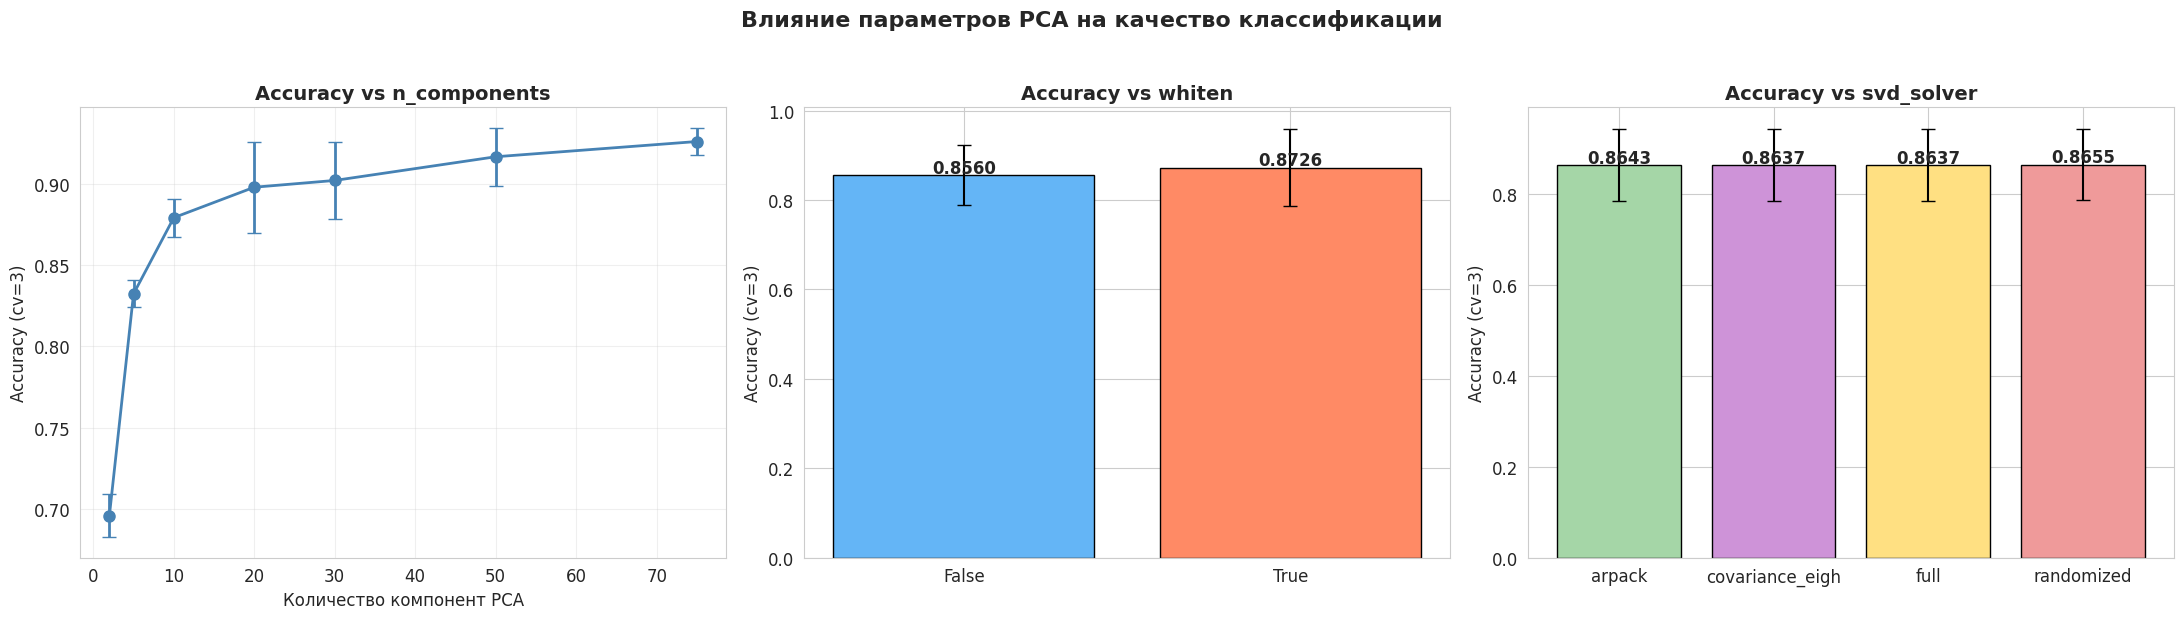

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1) n_components
nc_grouped = cv_results.groupby('param_pca__n_components')['mean_test_score'].agg(['mean', 'std'])
axes[0].errorbar(nc_grouped.index.astype(int), nc_grouped['mean'],
                 yerr=nc_grouped['std'], fmt='o-', lw=2, ms=8, capsize=5, color='steelblue')
axes[0].set_title('Accuracy vs n_components', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Количество компонент PCA')
axes[0].set_ylabel('Accuracy (cv=3)')
axes[0].grid(True, alpha=0.3)

# 2) whiten
wh_grouped = cv_results.groupby('param_pca__whiten')['mean_test_score'].agg(['mean', 'std'])
bars = axes[1].bar(['False', 'True'], wh_grouped['mean'], yerr=wh_grouped['std'],
                    color=['#64B5F6', '#FF8A65'], edgecolor='black', capsize=5)
for bar, v in zip(bars, wh_grouped['mean']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_title('Accuracy vs whiten', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy (cv=3)')

# 3) svd_solver
svd_grouped = cv_results.groupby('param_pca__svd_solver')['mean_test_score'].agg(['mean', 'std'])
bars = axes[2].bar(svd_grouped.index, svd_grouped['mean'], yerr=svd_grouped['std'],
                    color=['#A5D6A7', '#CE93D8', '#FFE082', '#EF9A9A'],
                    edgecolor='black', capsize=5)
for bar, v in zip(bars, svd_grouped['mean']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{v:.4f}', ha='center', fontweight='bold')
axes[2].set_title('Accuracy vs svd_solver', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Accuracy (cv=3)')

plt.suptitle('Влияние параметров PCA на качество классификации',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Прогнозы лучшей модели

In [19]:
best_model = grid_search.best_estimator_
best_pca_final = best_model.named_steps['pca']

y_pred = best_model.predict(X_test_pre)

print("=" * 60)
print("ПРОГНОЗЫ ЛУЧШЕЙ МОДЕЛИ")
print("=" * 60)
n_final = best_pca_final.n_components

print(f"\n  Исходных генов:          {X_train.shape[1]}")
print(f"  После предв. PCA:       200")
print(f"  Финальных компонент:     {n_final}")
print(f"  Общее сжатие:            в {X_train.shape[1] / n_final:.0f} раз")
print(f"  Объяснённая дисперсия:   {best_pca_final.explained_variance_ratio_.sum()*100:.1f}%")

comparison = pd.DataFrame({
    'Истинный класс': le.inverse_transform(y_test),
    'Предсказание': le.inverse_transform(y_pred),
    'Совпадение': ['✓' if a == b else '✗' for a, b in zip(y_test, y_pred)]
})
print(f"\nПервые 20 прогнозов:")
print(comparison.head(20).to_string(index=False))

correct = (y_pred == y_test).sum()
total = len(y_test)
print(f"\nПравильно: {correct} из {total} ({correct/total*100:.1f}%)")

ПРОГНОЗЫ ЛУЧШЕЙ МОДЕЛИ

  Исходных генов:          54676
  После предв. PCA:       200
  Финальных компонент:     50
  Общее сжатие:            в 1094 раз
  Объяснённая дисперсия:   74.9%

Первые 20 прогнозов:
Истинный класс Предсказание Совпадение
         basal        basal          ✓
     luminal_A    luminal_B          ✗
     luminal_B    luminal_B          ✓
     luminal_B    luminal_B          ✓
     luminal_A    luminal_A          ✓
         basal          HER          ✗
     cell_line    cell_line          ✓
         basal        basal          ✓
         basal        basal          ✓
     luminal_B    luminal_B          ✓
         basal        basal          ✓
           HER          HER          ✓
         basal        basal          ✓
           HER          HER          ✓
     luminal_A    luminal_A          ✓
        normal       normal          ✓
           HER          HER          ✓
     luminal_A    luminal_A          ✓
         basal        basal          ✓
     lumin

## Графики выходных результатов и метрики

In [20]:
print("=" * 60)
print("МЕТРИКИ КЛАССИФИКАЦИИ")
print("=" * 60)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\n  Accuracy:        {accuracy:.4f}")
print(f"  F1 (macro):      {f1_macro:.4f}")
print(f"  F1 (weighted):   {f1_weighted:.4f}")

print("\n" + "=" * 60)
print("ПОДРОБНЫЙ ОТЧЁТ ПО КЛАССАМ")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=class_names))

МЕТРИКИ КЛАССИФИКАЦИИ

  Accuracy:        0.9355
  F1 (macro):      0.9481
  F1 (weighted):   0.9354

ПОДРОБНЫЙ ОТЧЁТ ПО КЛАССАМ
              precision    recall  f1-score   support

         HER       0.86      1.00      0.92         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      0.83      0.91         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.94        31
   macro avg       0.95      0.95      0.95        31
weighted avg       0.94      0.94      0.94        31



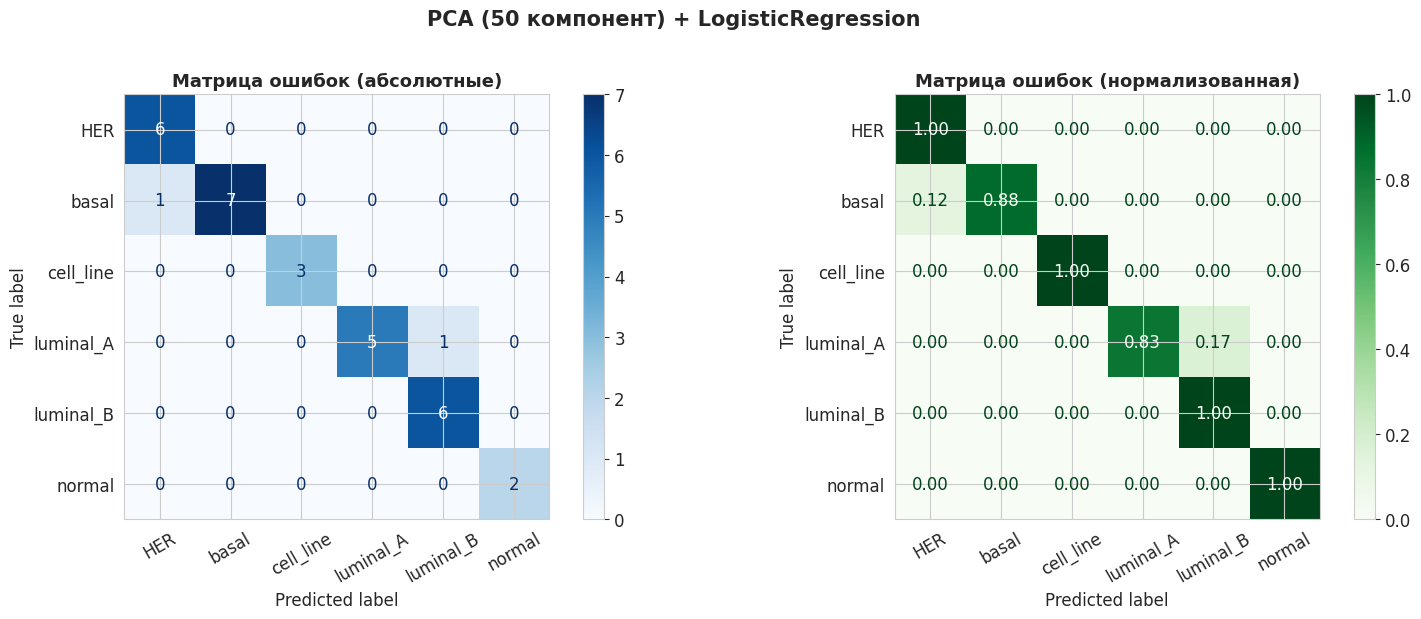

In [22]:
# Матрица ошибок
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Матрица ошибок (абсолютные)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(
    cmap='Greens', ax=axes[1], values_format='.2f')
axes[1].set_title('Матрица ошибок (нормализованная)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'PCA ({best_pca_final.n_components} компонент) + LogisticRegression',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Сравнение: без PCA vs с PCA
print("=" * 70)
print("СРАВНЕНИЕ: БЕЗ PCA vs С PCA")
print("=" * 70)

# Без PCA
clf_no_pca = LogisticRegression(max_iter=5000, random_state=42)
t0 = time.time()
clf_no_pca.fit(X_train, y_train)
time_no_pca = time.time() - t0
acc_no_pca = clf_no_pca.score(X_test, y_test)

# С PCA
t0 = time.time()
best_model.fit(X_train, y_train)
time_pca = time.time() - t0
acc_pca = best_model.score(X_test, y_test)

n_comp = grid_search.best_params_['pca__n_components']
print(f"\n  {'Метрика':<30} {'Без PCA':<15} {'С PCA ({0} комп.)':<20}".format(n_comp))
print(f"  {'-'*65}")
print(f"  {'Признаков':<30} {X_train.shape[1]:<15} {n_comp:<20}")
print(f"  {'Accuracy':<30} {acc_no_pca:<15.4f} {acc_pca:<20.4f}")
print(f"  {'Время обучения (сек)':<30} {time_no_pca:<15.4f} {time_pca:<20.4f}")
print(f"  {'Ускорение':<30} {'1x':<15} {time_no_pca/max(time_pca, 0.001):<20.1f}")
print(f"  {'Сжатие данных':<30} {'1x':<15} {X_train.shape[1]/n_comp:<20.0f}")

СРАВНЕНИЕ: БЕЗ PCA vs С PCA

  Метрика                        Без PCA         С PCA (50 комп.)   
  -----------------------------------------------------------------
  Признаков                      54676           50                  
  Accuracy                       0.9032          0.9355              
  Время обучения (сек)           1.0096          1.4305              
  Ускорение                      1x              0.7                 
  Сжатие данных                  1x              1094                
